# Recombinant Fitness Calculated with BVAS

In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from methods import Config, RecombBVASAnalysis

%matplotlib inline

# Load configuration file and data files required for analysis

In [5]:
# Ensure correct path to config.yaml file in top level directory
CONFIG_FILEPATH = "../config.yaml"
# Get all the data files from the config file
config = Config(CONFIG_FILEPATH)
analysis = RecombBVASAnalysis(config)

Loading all datasets for analysis
Data loaded, analysis ready. Elapsed time: 0.2727 seconds


TODO:

- First, lets check this file: data/rivet_recombs_bvas_data.csv and make sure these were calculated correctly.

- All sample statistics using BVAS -> Do this next, that way you can compute the rest of the statistics that you used.

- All sample statistics.

## Figure 3a: Mean and standard deviation of fitness for recombination

In [6]:
recombination_mean, recombination_std_dev = analysis.getRecombinationFitnessStats().values()
print("Mean fitness for recombinants found in MAT: ", recombination_mean)
print("Standard deviation of recombinants found in MAT: ", recombination_std_dev)

Mean fitness for recombinants found in MAT:  0.9538899412301841
Standard deviation of recombinants found in MAT:  0.1109077918929825


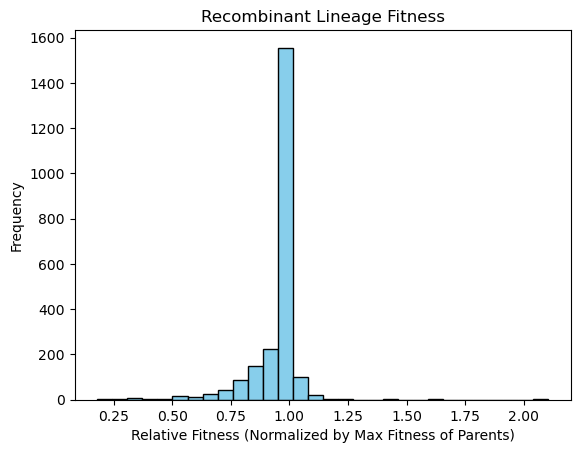

In [7]:
plt.hist(analysis.getRecombData()['RecombFitnessNormalizedByMaxParents'].to_list(), bins=30, color='skyblue', edgecolor='black')
plt.title('Recombinant Lineage Fitness')
plt.xlabel('Relative Fitness (Normalized by Max Fitness of Parents)')
plt.ylabel('Frequency')
plt.show()

# Figure 3b Analysis: Recombinant fitness normalized by the fitter parent, compared to parental divergence

### Percentage of recombinants that have near neutral fitness and arise from divergent parents

In [8]:
def neutral_and_divergent(df):
    """
    TODO
    """
    FITNESS_COL = "RecombFitnessNormalizedByMaxParents"
    DIVERGENCE_COL = "ParentsHD"

    TOTAL = len(df)
    avg_parental_divergence = df.select(pl.col(DIVERGENCE_COL).mean()).head(1).item()
    results = len(
        df.filter(
            (pl.col(FITNESS_COL).is_between(0.98, 1.02))
            & (pl.col(DIVERGENCE_COL) > avg_parental_divergence)
        )
    )
    print("Percentage of recombinants that are near neutral and divergent cases: ", (results / TOTAL) * 100)

In [9]:
neutral_and_divergent(analysis.getRecombData())

Percentage of recombinants that are near neutral and divergent cases:  16.107678729037954


### Percentage of recombinants that are significantly fitter than both parents and arise from divergent parents 

In [10]:
def divergent_and_highly_fit(df, FITNESS_THRESHOLD = 1.1):
    """
    """
    FITNESS_COL = "RecombFitnessNormalizedByMaxParents"
    DIVERSITY_COL = "ParentsHD"
    
    avg_parental_divergence = df.select(pl.col(DIVERSITY_COL).mean()).head(1).item()
    TOTAL = len(df)
    
    # Above 1.1 norm fitness and high diversity
    results = len(
        df.filter(
            (pl.col(FITNESS_COL) > FITNESS_THRESHOLD)
            & (pl.col(DIVERSITY_COL) > avg_parental_divergence)
        )
    )
    result_percentage = (results / TOTAL) * 100
    print("Percentage of recombinants that are significantly fitter than both parents and the parents are divergent: ", result_percentage)

In [11]:
divergent_and_highly_fit(analysis.getRecombData())

Percentage of recombinants that are significantly fitter than both parents and the parents are divergent:  0.39717563989408644


# Figure 3c Analysis: Calculating the mean and standard deviation of recombinant fitness when normalized by minimum of parental fitness

In [12]:
recombination_norm_by_min_mean, recombination_norm_by_min_std_dev = analysis.getRecombinationMinFitnessStats().values()
print("Mean fitness for recombinants (normalized by min of parental fitness) found in MAT: ", recombination_norm_by_min_mean)
print("Standard deviation of recombinants (normalized by min of parental fitness) found in MAT: ", recombination_norm_by_min_std_dev)

Mean fitness for recombinants (normalized by min of parental fitness) found in MAT:  1.095466149976216
Standard deviation of recombinants (normalized by min of parental fitness) found in MAT:  0.2533763919604416


# Figure 3d Analysis: Recombinant fitness compared to parental fitness

In [13]:
def calculate_percentages(data):
    """
    """
    total = len(data)
    between_0_and_1 = np.sum((data >= 0) & (data <= 1))
    below_0 =  np.sum(data < 0)
    above_1 = np.sum(data > 1)
    assert(total == (between_0_and_1 + below_0 + above_1))

    print("Percentage of data below 0: ", round((below_0 / total) * 100, 2))
    print("Percentage of data above 1: ", round((above_1 / total) * 100, 2))
    print("Percentage of data between 0 and 1 (both inclusive): ", round((between_0_and_1 / total) * 100, 2))

In [14]:
norm_fitness_data = analysis.getNormFitness().select('NormFitness').to_numpy()
calculate_percentages(norm_fitness_data)

Percentage of data below 0:  14.7
Percentage of data above 1:  20.08
Percentage of data between 0 and 1 (both inclusive):  65.23
